[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maxencegu/python-datascience-l3/blob/main/assignments/td01_introduction_a_git/td01_enonce.ipynb)

# **Introduction**

Imaginez que vous travaillez depuis trois semaines sur un script d'analyse économétrique.
Un matin, vous modifiez une ligne, relancez le modèle — et vos résultats s'effondrent.
Vous ne savez plus quelle version du code fonctionnait, ni ce que vous avez changé.

C'est exactement le problème que **Git** résout.

Git est un **logiciel de gestion de versions** : il enregistre l'historique complet de vos fichiers,
commit après commit, comme une suite de photos de votre projet à des instants précis.
À tout moment, vous pouvez consulter ce qui a changé, qui l'a changé, et pourquoi —
ou revenir à une version antérieure en une seule commande.

Initialement conçu pour les développeurs, Git est aujourd'hui indispensable dans tous
les domaines qui manipulent des données : économie, finance, recherche, data science.
Versionner un notebook Python ou un fichier `.csv`, c'est exactement le même principe
que versionner du code : chaque modification est traçable, réversible, et documentée.

Dans ce TD, vous apprendrez à :
- naviguer dans votre système de fichiers depuis le terminal ;
- initialiser un dépôt Git et suivre vos fichiers ;
- créer des commits pour sauvegarder l'évolution de votre travail ;
- consulter et comparer différentes versions de vos fichiers ;
- corriger une erreur en restaurant une version précédente.

À l'issue de cette séance, vous disposerez des bases pour ne plus jamais perdre
une version de votre travail.

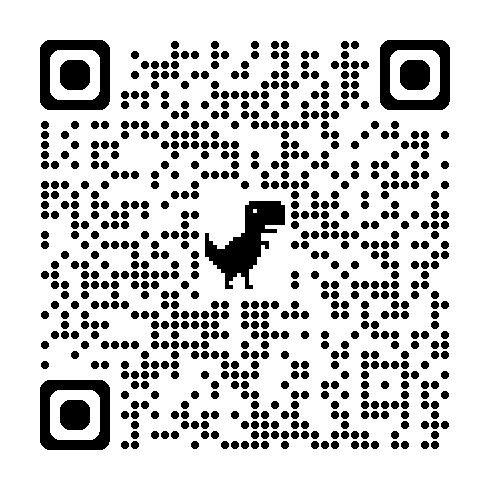

In [ ]:
# @title 📋 Feuille de présence (remplir maintenant)
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">📋 Feuille de présence</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td01_introduction_a_git/assets/qr_td01_presence.png", width=250))
display(HTML('<a href="https://forms.gle/QY9o9Pjzp7vwyqex6" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le formulaire</button></a>'))

In [ ]:
# @title Configuration des ressources (ne pas modifier)
from IPython.display import Image, display

BASE_URL = "https://raw.githubusercontent.com/Maxencegu/python-datascience/main/assignments/td01_introduction_a_git/images/"

def afficher_infographie(nom_fichier, largeur=1300):
    display(Image(url=BASE_URL + nom_fichier, width=largeur))

# **1. Introduction à Git**

## **1.1 Introduction à Git**

Découvrez les avantages et les bases de Git pour la gestion de versions dans les projets logiciels et de données.

In [ ]:
# @title Infographie — La gestion de versions
afficher_infographie("01_gestion_de_versions_pour_economistes.png")

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os

os.chdir("/content")
os.makedirs("/content/data/brut", exist_ok=True)
os.makedirs("/content/data/traite", exist_ok=True)
open("/content/data/salaires_2023.csv", "w").close()
open("/content/data/brut/enquete.csv", "w").close()
print("✅ Environnement prêt — vous êtes dans :", os.getcwd())

✅ Environnement prêt — vous êtes dans : /content


In [ ]:
# @title Exercice — Naviguer dans le shell
# ================================================================
#  EXERCICE — Naviguer dans le shell                    [ 3 étapes ]
# ================================================================
#
# Syntaxe pour capturer la sortie : result = !commande
#
# ----------------------------------------------------------------
# Étape 1/3 — Affichez et capturez le répertoire courant
# ----------------------------------------------------------------
rep_courant = !pwd
print(rep_courant[0])

# ----------------------------------------------------------------
# Étape 2/3 — Allez dans le répertoire data
# Note : utilisez %cd (pas !cd) pour un changement permanent
# ----------------------------------------------------------------
%cd data

# ----------------------------------------------------------------
# Étape 3/3 — Listez et capturez le contenu du répertoire
# ----------------------------------------------------------------
contenu = !ls
print('\n'.join(contenu))

/content
/content/data
brut  salaires_2023.csv  traite


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# @title ✅ Vérification
import os

FICHIERS_ATTENDUS = {"salaires_2023.csv", "brut", "traite"}

def verifier(etape, condition, ok, ko):
    print(f"  {'✅' if condition else '❌'} Étape {etape} : {ok if condition else ko}")

print("Résultats :\n")

# Étape 1 : rep_courant doit exister et contenir un chemin
try:
    verifier(1, isinstance(rep_courant, list) and len(rep_courant) > 0,
        f"Répertoire capturé → {rep_courant[0]}",
        "rep_courant est vide ou n'existe pas — avez-vous utilisé !pwd ?")
except NameError:
    print("  ❌ Étape 1 : rep_courant n'est pas défini")

# Étape 2 : doit être dans data/
rep_actuel = os.getcwd()
verifier(2, rep_actuel.endswith("/data"),
    "Vous êtes dans data/",
    f"Vous êtes dans {rep_actuel} — utilisez %cd data")

# Étape 3 : contenu doit lister les fichiers créés dans data/
try:
    a_capture = isinstance(contenu, list) and len(contenu) > 0
    fichiers_reels = set(os.listdir("."))          # indépendant du format de ls
    fichiers_ok = FICHIERS_ATTENDUS.issubset(fichiers_reels)

    verifier(3, a_capture and fichiers_ok,
        f"Contenu listé → {sorted(fichiers_reels)}",
        f"Fichiers manquants : {FICHIERS_ATTENDUS - fichiers_reels}" if a_capture
        else "contenu n'est pas défini — avez-vous utilisé !ls -1 ?")
except NameError:
    print("  ❌ Étape 3 : contenu n'est pas défini")

Résultats :

  ✅ Étape 1 : Répertoire capturé → /content
  ✅ Étape 2 : Vous êtes dans data/
  ✅ Étape 3 : Contenu listé → ['brut', 'salaires_2023.csv', 'traite']


In [ ]:
# @title 🔧 Exercice — Vérifier la version de Git
# ================================================================
#  EXERCICE — Vérifier la version de Git               [ 1 étape ]
# ================================================================
#
# Syntaxe pour capturer la sortie : result = !commande
#
# ----------------------------------------------------------------
# Affichez la version de Git installée dans ce terminal
# ----------------------------------------------------------------
version_git = !git --version
print(version_git[0])

git version 2.43.0


In [ ]:
# @title ✅ Vérification
try:
    ok = isinstance(version_git, list) and version_git[0].startswith("git version")
    if ok:
        print(f"  ✅ Git est installé → {version_git[0]}")
    else:
        print(f"  ❌ Résultat inattendu : {version_git[0]}")
except NameError:
    print("  ❌ version_git n'est pas défini — avez-vous utilisé !git --version ?")


  ✅ Git est installé → git version 2.43.0


---
---

## **1.2 Création de dépôts**

In [ ]:
# @title Infographie — La création des dépôts
afficher_infographie("02_guide_git_pour_les_economistes_pro.png")

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os

os.chdir("/content")
os.makedirs("mh_survey/data", exist_ok=True)
open("mh_survey/report.md", "w").write("# Rapport santé mentale dans les technologies")
open("mh_survey/funding.doc", "w").write("Budget du projet : 50 000 €")
open("mh_survey/data/survey_results.csv", "w").write("id,score,poste\n1,7,développeur\n2,4,designer\n")

%cd /content/mh_survey
print("✅ Vous êtes dans :", os.getcwd())
print("📁 Contenu du projet :", os.listdir("."))

/content/mh_survey
✅ Vous êtes dans : /content/mh_survey
📁 Contenu du projet : ['mh_survey', 'report.md', 'data', 'funding.doc']


In [ ]:
# @title 🔧 Exercice — Convertir un projet existant en dépôt Git
# ================================================================
#  EXERCICE — Conversion d'un projet existant          [ 1 étape ]
# ================================================================
#
# Vous êtes dans le répertoire mh_survey.
# Ce projet existe déjà mais n'est pas encore suivi par Git.
#
# ----------------------------------------------------------------
# Transformez le répertoire actuel en dépôt Git
# ----------------------------------------------------------------
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/mh_survey/.git/


In [ ]:
# @title ✅ Vérification
import os

print("Résultats :\n")

bon_rep = os.getcwd().endswith("mh_survey")
git_existe = os.path.isdir(".git")

print(f"  {'✅' if bon_rep else '❌'} Répertoire courant → {os.getcwd()}")
print(f"  {'✅' if git_existe else '❌'} Dépôt Git initialisé (.git présent)")

if not git_existe:
    print("\n  💡 Indice : utilisez git init sans argument pour convertir le répertoire actuel")

Résultats :

  ✅ Répertoire courant → /content/mh_survey
  ✅ Dépôt Git initialisé (.git présent)


---
---

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os

os.chdir("/content")

# Repart d'un état propre si l'exercice est relancé
import shutil
if os.path.exists("stress-performance"):
    shutil.rmtree("stress-performance")

print("✅ Environnement prêt — vous êtes dans :", os.getcwd())

✅ Environnement prêt — vous êtes dans : /content


In [ ]:
# @title 🔧 Exercice — Créer un nouveau dépôt Git
# ================================================================
#  EXERCICE — Création d'un nouveau dépôt              [ 3 étapes ]
# ================================================================
#
# ----------------------------------------------------------------
# Étape 1/3 — Créez un nouveau dépôt Git appelé stress-performance
# ----------------------------------------------------------------
!git init stress-performance

# ----------------------------------------------------------------
# Étape 2/3 — Allez dans le répertoire stress-performance
# Note : utilisez %cd (pas !cd) pour un changement permanent
# ----------------------------------------------------------------
%cd stress-performance

# ----------------------------------------------------------------
# Étape 3/3 — Vérifiez l'état du nouveau dépôt
# ----------------------------------------------------------------
statut = !git status
print('\n'.join(statut))

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/stress-performance/.git/
/content/stress-performance
On branch master

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [ ]:
# @title ✅ Vérification
import os

print("Résultats :\n")

# Étape 1 : chemin absolu — fonctionne même si on est déjà dans le dossier
git_existe = os.path.isdir("/content/stress-performance/.git")
print(f"  {'✅' if git_existe else '❌'} Étape 1 : dépôt stress-performance créé (.git présent)"
      + ("" if git_existe else "\n             💡 Indice : git init stress-performance"))

# Étape 2 : répertoire courant
bon_rep = os.getcwd().endswith("stress-performance")
print(f"  {'✅' if bon_rep else '❌'} Étape 2 : vous êtes dans → {os.getcwd()}"
      + ("" if bon_rep else "\n             💡 Indice : utilisez %cd stress-performance"))

# Étape 3 : statut capturé et contient bien une sortie git
try:
    contient_git = isinstance(statut, list) and any("branch" in ligne.lower() for ligne in statut)
    print(f"  {'✅' if contient_git else '❌'} Étape 3 : git status exécuté"
          + ("" if contient_git else "\n             💡 Indice : statut = !git status"))
except NameError:
    print("  ❌ Étape 3 : statut n'est pas défini")

Résultats :

  ✅ Étape 1 : dépôt stress-performance créé (.git présent)
  ✅ Étape 2 : vous êtes dans → /content/stress-performance
  ✅ Étape 3 : git status exécuté


---
---

## **1.3 Maîtriser le Flux de Travail Git : Staging et Commit**

In [ ]:
# @title Infographie — La maîtrise de son flux de travail avec git
afficher_infographie("03_maitriser_le_flux_git_pro.png")

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil

os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey")
open("mh_survey/report.md", "w").write("# Rapport — Santé mentale dans les technologies\n")

os.chdir("mh_survey")
os.system("git init -q")

print("✅ Environnement prêt :", os.getcwd())
print("📄 Fichiers présents :", os.listdir("."))

✅ Environnement prêt : /content/mh_survey
📄 Fichiers présents : ['report.md', '.git']


In [ ]:
# @title 🔧 Exercice — Ajouter un fichier à la zone de staging
# ================================================================
#  EXERCICE — Zone de staging                          [ 1 étape ]
# ================================================================
#
# Vous avez créé report.md dans votre répertoire de travail.
# Git ne suit pas encore ce fichier.
#
# ----------------------------------------------------------------
# Placez report.md dans la zone de staging
# ----------------------------------------------------------------
!git add report.md

In [ ]:
# @title ✅ Vérification
fichiers_stagés = !git diff --cached --name-only

print("Résultats :\n")

is_staged = "report.md" in fichiers_stagés
print(f"  {'✅' if is_staged else '❌'} report.md dans la zone de staging")

if not is_staged:
    # Aide au diagnostic
    statut = !git status --porcelain
    if statut:
        print(f"\n  État actuel des fichiers : {statut}")
    else:
        print("\n  💡 Le répertoire semble vide — avez-vous exécuté la cellule setup ?")

Résultats :

  ✅ report.md dans la zone de staging


---
---

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil

statut = ""
os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey/data")
open("mh_survey/report.md", "w").write("# Rapport santé mentale\n\n## Participants\n- Participant 1 : score 7\n")
open("mh_survey/data/mental_health_survey.csv", "w").write("id,score,poste\n1,7,développeur\n2,4,designer\n")

os.chdir("mh_survey")
os.system("git init -q")
os.system('git config user.email "etudiant@upjv.fr"')
os.system('git config user.name "Etudiant"')
os.system("git add .")
os.system('git commit -q -m "Initial commit"')

# Modifications simulant le travail de l'étudiant
with open("report.md", "a") as f:
    f.write("- Participant 3 : score 8\n- Participant 4 : score 5\n\n## To-do\n- [x] Collecter les données\n- [ ] Analyser les résultats\n")
with open("data/mental_health_survey.csv", "a") as f:
    f.write("3,8,manager\n4,5,designer\n")

print("✅ Environnement prêt —", os.getcwd())
print("📝 Modifications en attente :")
os.system("git status --short")

✅ Environnement prêt — /content/mh_survey
📝 Modifications en attente :


0

In [ ]:
# @title 🔧 Exercice — Sauvegarder les fichiers
# ================================================================
#  EXERCICE — Staging et commit                        [ 3 étapes ]
# ================================================================
#
# report.md et data/mental_health_survey.csv ont été modifiés.
#
# ----------------------------------------------------------------
# Étape 1/3 — Ajoutez les deux fichiers modifiés en une seule commande
# ----------------------------------------------------------------
!git add .

# ----------------------------------------------------------------
# Étape 2/3 — Consultez l'état des fichiers
# ----------------------------------------------------------------
statut = !git status
print('\n'.join(statut))

# ----------------------------------------------------------------
# Étape 3/3 — Effectuez un commit avec le message suivant :
# "Add 2 participants and update to-do list."
# ----------------------------------------------------------------
!git commit -m "Add 2 participants and update to-do list."

On branch master
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   data/mental_health_survey.csv
	modified:   report.md

[master dae42d6] Add 2 participants and update to-do list.
 2 files changed, 8 insertions(+)


In [ ]:
# @title ✅ Vérification
import os

print("Résultats :\n")

# Étape 1 : les deux fichiers sont stagés
stagés = !git diff --cached --name-only HEAD~1
tous_stagés = "report.md" in '\n'.join(stagés) and "mental_health_survey.csv" in '\n'.join(stagés)

# Si déjà commités, on vérifie dans le dernier commit
if not tous_stagés:
    dernier_commit = !git diff --name-only HEAD~1 HEAD
    tous_stagés = "report.md" in '\n'.join(dernier_commit) and "mental_health_survey.csv" in '\n'.join(dernier_commit)

print(f"  {'✅' if tous_stagés else '❌'} Étape 1 : les deux fichiers ajoutés en une commande"
      + ("" if tous_stagés else "\n             💡 Indice : git add ."))

# Étape 2 : statut capturé
try:
    statut_ok = isinstance(statut, list) and len(statut) > 0
    print(f"  {'✅' if statut_ok else '❌'} Étape 2 : git status exécuté"
          + ("" if statut_ok else "\n             💡 Indice : statut = !git status"))
except NameError:
    print("  ❌ Étape 2 : statut n'est pas défini")

# Étape 3 : message du dernier commit
dernier_message = !git log --oneline -1
message_attendu = "Add 2 participants and update to-do list."
message_ok = any(message_attendu in ligne for ligne in dernier_message)
print(f"  {'✅' if message_ok else '❌'} Étape 3 : commit avec le bon message"
      + ("" if message_ok else f"\n             Message trouvé  : {dernier_message[0] if dernier_message else 'aucun'}"
                               f"\n             Message attendu : {message_attendu}"))

Résultats :

  ✅ Étape 1 : les deux fichiers ajoutés en une commande
  ✅ Étape 2 : git status exécuté
  ✅ Étape 3 : commit avec le bon message


---
---

# 📚 Vos apprentissages récents

## ✅ Ce que vous avez appris grâce au chapitre 1

Vous avez découvert les étapes essentielles pour **suivre** et **enregistrer** les modifications dans un dépôt Git.

### 📌 La zone de staging

La **zone de staging** est l'endroit où Git prépare les fichiers avant leur enregistrement définitif.

> 💡 Pensez-y comme au fait de **mettre une lettre dans une enveloppe** avant de l'envoyer.

### 📌 Le commit

Faire un **commit** revient à enregistrer un instantané de votre projet à un instant donné.

> 💡 C'est comme **déposer l'enveloppe dans une boîte aux lettres**.

---

# 💻 Les commandes essentielles

## Ajouter un fichier à la zone de staging

```bash
git add report.md
```

Cette commande ajoute le fichier `report.md` à la zone de staging.

---

## Ajouter tous les fichiers modifiés

```bash
git add .
```

Cette commande ajoute **tous les fichiers modifiés** du répertoire courant (et de ses sous-répertoires) à la zone de staging.

---

## Créer un commit

```bash
git commit -m "Votre message de log ici"
```

Cette commande crée un **commit** contenant tous les fichiers présents dans la zone de staging.

---

# 📝 Bonnes pratiques

- Écrire un **message de commit clair et concis**.
- Le message doit permettre de comprendre rapidement les modifications apportées.

---

## **1.4 Historique des versions**

Découvrez comment comparer des fichiers à différents moments et restaurer des fichiers à un état antérieur.

In [ ]:
# @title Infographie — Affichage de l'historique des versions
afficher_infographie("04_affichage_de_l_historique_des_versions_pro.png")

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil

os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey/data")
os.chdir("mh_survey")
os.system("git init -q")
os.system('git config user.email "etudiant@upjv.fr"')
os.system('git config user.name "Etudiant"')

# Commit 1
open("report.md", "w").write("# Rapport santé mentale\n")
os.system("git add report.md")
os.system('git commit -q -m "Initial commit"')

# Commit 2
open("data/mental_health_survey.csv", "w").write("id,score,poste\n1,7,développeur\n2,4,designer\n")
os.system("git add data/mental_health_survey.csv")
os.system('git commit -q -m "Add survey data"')

# Commit 3
with open("report.md", "a") as f:
    f.write("\n## Participants\n- 2 participants recrutés\n")
os.system("git add report.md")
os.system('git commit -q -m "Add 2 participants and update to-do list."')

print("✅ Dépôt prêt avec", os.popen("git rev-list --count HEAD").read().strip(), "commits")

✅ Dépôt prêt avec 3 commits


In [ ]:
# @title 🔧 Exercice — Afficher l'historique d'un dépôt
# ================================================================
#  EXERCICE — Historique Git                           [ 1 étape ]
# ================================================================
#
# Chaque commit possède un identifiant unique appelé hash.
#
# ----------------------------------------------------------------
# Affichez tous les commits du dépôt avec leur hash, auteur et date
# ----------------------------------------------------------------
historique = !git log
print('\n'.join(historique))

commit 88a05b0d253c1df761410d0799a171e29454a674 (HEAD -> master)
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:03:47 2026 +0000

    Add 2 participants and update to-do list.

commit fcbccbc99d7c8613fd94072726484845b7ad5993
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:03:47 2026 +0000

    Add survey data

commit 34dca761df169e5783c3b065b0e07c4214336304
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:03:47 2026 +0000

    Initial commit


In [ ]:
# @title ✅ Vérification
import re

print("Résultats :\n")

try:
    # Hash réel du dernier commit dans ce dépôt
    hash_reel = !git rev-parse HEAD
    hash_court = hash_reel[0][:7]

    # Vérification : la sortie contient-elle un hash valide ?
    sortie = '\n'.join(historique)
    contient_hash = bool(re.search(r'[0-9a-f]{7,40}', sortie))
    contient_dernier = hash_court in sortie

    print(f"  {'✅' if contient_hash else '❌'} Historique affiché avec des hashs")
    print(f"  {'✅' if contient_dernier else '❌'} Hash du dernier commit visible → {hash_court}")

    if contient_hash and not contient_dernier:
        print(f"\n  💡 Le hash du dernier commit est {hash_court}")
        print("     Vérifiez que votre commande affiche bien le commit le plus récent en premier.")

    if contient_dernier:
        print(f"\n  Le dépôt contient {len([l for l in historique if hash_court[:4] in l or 'commit' in l.lower()])} commits.")

except NameError:
    print("  ❌ historique n'est pas défini")

Résultats :

  ✅ Historique affiché avec des hashs
  ✅ Hash du dernier commit visible → 88a05b0

  Le dépôt contient 4 commits.


---
---

In [ ]:
# @title Infographie — Trucs et astuces sur l'historique des versions
afficher_infographie("05_trucs_et_astuces_sur_l_historique_git_pro.png")

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil

os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey/data")
os.chdir("mh_survey")
os.system("git init -q")
os.system('git config user.email "etudiant@upjv.fr"')
os.system('git config user.name "Etudiant"')

commits = [
    ("report.md",                     "# Rapport initial\n",             "Initial commit"),
    ("data/mental_health_survey.csv", "id,score\n1,7\n2,4\n",           "Fichier de données CSV ajouté"),
    ("summary.md",                    "# Synthèse\n",                    "Fichier de rapport de synthèse ajouté."),
    ("data/mental_health_survey.csv", "id,score\n1,7\n2,4\n3,8\n4,5\n", "Ajout de nouvelles données pour l'enquête."),
    ("report.md",                     "# Rapport final\n## Conclusion\n","Rappel pour citer les sources de financement ajouté."),
]

for fichier, contenu, message in commits:
    open(fichier, "w").write(contenu)
    os.system(f"git add {fichier}")
    os.system(f'git commit -q -m "{message}"')

total = !git rev-list --count HEAD
print(f"✅ Dépôt prêt — {total[0]} commits disponibles")
print("\nHistorique complet :")
os.system("git log --oneline")

try:
    del journal
except NameError:
    pass


✅ Dépôt prêt — 5 commits disponibles

Historique complet :


In [ ]:
# @title 🔧 Exercice — Limiter l'affichage de l'historique
# ================================================================
#  EXERCICE — git log limité                           [ 1 étape ]
# ================================================================
#
# Le dépôt contient plusieurs commits.
# Vous n'avez besoin que des informations sur les deux derniers.
#
# ----------------------------------------------------------------
# Affichez uniquement les deux derniers commits
# ----------------------------------------------------------------
journal = !git log -2
print('\n'.join(journal))

commit 4866fca724c1d86e16342f8d9882176fdf2e4aa0 (HEAD -> master)
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:05:24 2026 +0000

    Rappel pour citer les sources de financement ajouté.

commit 81c0ed019dd349ee369c40f492f32c917c1204eb
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:05:24 2026 +0000

    Ajout de nouvelles données pour l'enquête.


In [ ]:
# @title ✅ Vérification
print("Résultats :\n")

try:
    sortie = '\n'.join(journal)

    nb_commits_full    = sortie.count("\ncommit ") + (1 if sortie.startswith("commit ") else 0)
    nb_commits_oneline = len([l for l in journal if l.strip()
                               and not l.startswith(" ")
                               and not l.startswith("\t")
                               and not l.startswith("Author")
                               and not l.startswith("Date")
                               and not l.startswith("Merge")])

    nb_commits = nb_commits_full if nb_commits_full > 0 else nb_commits_oneline
    exactement_2 = nb_commits == 2

    icone = '✅' if exactement_2 else '❌'
    print(f"  {icone} Exactement 2 commits affichés (trouvé : {nb_commits})")

    if not exactement_2:
        if nb_commits > 2:
            print("     💡 Indice : git log accepte une option numérique pour limiter le nombre de commits affichés")
        elif nb_commits == 0:
            print("     💡 Indice : capturez la sortie de git log dans une variable, en limitant l'affichage")
        else:
            print("     💡 Indice : ajustez l'option pour afficher exactement 2 commits")

except NameError:
    print("  ❌ journal n'est pas défini")
    print("     💡 Indice : capturez la sortie de git log dans une variable, en limitant le nombre de commits")

Résultats :

  ✅ Exactement 2 commits affichés (trouvé : 2)


---
---

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil

os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey/data")
os.chdir("mh_survey")
os.system("git init -q")
os.system('git config user.email "etudiant@upjv.fr"')
os.system('git config user.name "Etudiant"')

commits = [
    ("report.md",                     "# Rapport initial\n",             "Initial commit"),
    ("data/mental_health_survey.csv", "id,score\n1,7\n2,4\n",           "Fichier de données CSV ajouté"),
    ("summary.md",                    "# Synthèse\n",                    "Fichier de rapport de synthèse ajouté"),
    ("data/mental_health_survey.csv", "id,score\n1,7\n2,4\n3,8\n4,5\n", "Ajout de nouvelles données pour l'enquête"),
    ("report.md",                     "# Rapport final\n## Conclusion\n","Rappel pour citer les sources de financement ajouté"),
]

for fichier, contenu, message in commits:
    open(fichier, "w").write(contenu)
    os.system(f"git add {fichier}")
    os.system(f'git commit -q -m "{message}"')

print("✅ Dépôt prêt\n")
print("Historique complet (avec fichiers modifiés) :")
os.system("git log --oneline --name-only")

try:
    del journal
except NameError:
    pass


✅ Dépôt prêt

Historique complet (avec fichiers modifiés) :


In [ ]:
# @title 🔧 Exercice — Historique d'un fichier
# ================================================================
#  EXERCICE — git log filtré par fichier              [ 1 étape ]
# ================================================================
#
# Le dépôt contient plusieurs commits affectant différents fichiers.
# Vous souhaitez isoler uniquement les modifications de report.md.
#
# ----------------------------------------------------------------
# Affichez les 2 derniers commits concernant uniquement report.md
# ----------------------------------------------------------------

# Combinez la limitation du nombre de commits et le ciblage d'un fichier
journal = !git log -2 donnees.csv
print('\n'.join(journal))

fatal: ambiguous argument 'donnees.csv': unknown revision or path not in the working tree.
Use '--' to separate paths from revisions, like this:
'git <command> [<revision>...] -- [<file>...]'


In [ ]:
# @title ✅ Vérification
print("Résultats :\n")

try:
    sortie = '\n'.join(journal)

    nb_commits_full    = sortie.count("\ncommit ") + (1 if sortie.startswith("commit ") else 0)
    nb_commits_oneline = len([l for l in journal if l.strip()
                               and not l.startswith(" ")
                               and not l.startswith("\t")
                               and not l.startswith("Author")
                               and not l.startswith("Date")
                               and not l.startswith("Merge")])
    nb_commits = nb_commits_full if nb_commits_full > 0 else nb_commits_oneline
    exactement_2 = nb_commits == 2

    icone = '✅' if exactement_2 else '❌'
    print(f"  {icone} Exactement 2 commits affichés (trouvé : {nb_commits})")

    if not exactement_2:
        if nb_commits > 2:
            print("     💡 Indice : git log accepte un argument pour restreindre l'historique à un fichier précis")
        elif nb_commits == 0:
            print("     💡 Indice : vérifiez l'orthographe du fichier ciblé")
        else:
            print("     💡 Indice : ajustez les arguments pour obtenir exactement 2 commits sur ce fichier")

    # Vérifie que les commits affichés sont bien ceux de report.md
    if exactement_2:
        ref_hashes = !git log --format=%H -- report.md
        cible_report = all(h[:10] in sortie for h in ref_hashes)
        icone2 = '✅' if cible_report else '❌'
        print(f"  {icone2} Les commits affichés concernent bien report.md")
        if not cible_report:
            print("     💡 Indice : vérifiez le nom du fichier passé en argument")

except NameError:
    print("  ❌ journal n'est pas défini")
    print("     💡 Indice : capturez la sortie de git log dans une variable, en ciblant un fichier spécifique")

Résultats :

  ✅ Exactement 2 commits affichés (trouvé : 2)
  ✅ Les commits affichés concernent bien report.md


---
---

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil, datetime

os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey/data")
os.chdir("mh_survey")
os.system("git init -q")
os.system('git config user.email "etudiant@upjv.fr"')
os.system('git config user.name "Etudiant"')

il_y_a_deux_semaines = (datetime.date.today() - datetime.timedelta(weeks=2)).strftime("%Y-%m-%d")
os.environ["GIT_AUTHOR_DATE"]    = f"{il_y_a_deux_semaines} 10:00:00"
os.environ["GIT_COMMITTER_DATE"] = f"{il_y_a_deux_semaines} 10:00:00"

anciens = [
    ("data/mental_health_survey.csv", "id,score\n1,7\n2,4\n",   "Importation initiale des données"),
    ("report.md",                     "# Rapport\n",             "Création du rapport"),
    ("summary.md",                    "# Synthèse\n",            "Ajout de la synthèse"),
]
for fichier, contenu, message in anciens:
    open(fichier, "w").write(contenu)
    os.system(f"git add {fichier}")
    os.system(f'git commit -q -m "{message}"')

del os.environ["GIT_AUTHOR_DATE"]
del os.environ["GIT_COMMITTER_DATE"]

recents = [
    ("data/mental_health_survey.csv", "id,score\n1,7\n2,4\n3,8\n4,5\n", "Correction des données d'enquête"),
    ("report.md",                     "# Rapport final\n## Conclusion\n", "Ajout de la conclusion au rapport"),
]
for fichier, contenu, message in recents:
    open(fichier, "w").write(contenu)
    os.system(f"git add {fichier}")
    os.system(f'git commit -q -m "{message}"')

print("✅ Dépôt prêt\n")
print("Historique complet :")
os.system("git log --pretty='%h  %ad  %s' --date=short")

# Réinitialise les variables de l'exercice précédent
try:
    del journal
except NameError:
    pass

✅ Dépôt prêt

Historique complet :


In [ ]:
# @title 🔧 Exercice — Filtrer par date
# ================================================================
#  EXERCICE — git log filtré par date                 [ 1 étape ]
# ================================================================
#
# Le dépôt contient des commits répartis sur plusieurs semaines.
# Vous souhaitez ne voir que ce qui a été accompli aujourd'hui.
#
# ----------------------------------------------------------------
# Affichez uniquement les commits effectués depuis hier
# ----------------------------------------------------------------

# Utilisez un drapeau pour filtrer les commits par date
journal = !git log --since "yesterday"
print('\n'.join(journal))

commit e21a6f50d7f3a8b5e8dc11323e26f3f18fcb2f61 (HEAD -> master)
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:10:12 2026 +0000

    Ajout de la conclusion au rapport

commit 98cde74de40d97766aa99cc82621891442cea50e
Author: Etudiant <etudiant@upjv.fr>
Date:   Wed Sep 16 17:10:12 2026 +0000

    Correction des données d'enquête


In [ ]:
# @title ✅ Vérification
import subprocess, datetime

print("Résultats :\n")

try:
    sortie = '\n'.join(journal)

    nb_commits_full    = sortie.count("\ncommit ") + (1 if sortie.startswith("commit ") else 0)
    nb_commits_oneline = len([l for l in journal if l.strip()
                               and not l.startswith(" ")
                               and not l.startswith("\t")
                               and not l.startswith("Author")
                               and not l.startswith("Date")
                               and not l.startswith("Merge")])
    nb_commits = nb_commits_full if nb_commits_full > 0 else nb_commits_oneline

    # Référence : commits depuis hier (calcul indépendant)
    hier = (datetime.date.today() - datetime.timedelta(days=1)).isoformat()
    ref = subprocess.run(
        ["git", "log", "--oneline", f"--since={hier}"],
        capture_output=True, text=True
    )
    nb_ref = len([l for l in ref.stdout.strip().split('\n') if l])

    filtre_applique = nb_commits == nb_ref and nb_commits > 0

    icone = '✅' if filtre_applique else '❌'
    print(f"  {icone} Filtre date correctement appliqué (commits récents : {nb_commits})")

    if not filtre_applique:
        if nb_commits == 0:
            print("     💡 Indice : vérifiez le drapeau et la valeur de date utilisés")
        elif nb_commits > nb_ref:
            print("     💡 Indice : trop de commits affichés — la date de référence est peut-être trop ancienne")
        else:
            print("     💡 Indice : trop peu de commits — la date de référence est peut-être trop récente")

except NameError:
    print("  ❌ journal n'est pas défini")
    print("     💡 Indice : capturez la sortie de git log dans une variable, en filtrant par date")

Résultats :

  ✅ Filtre date correctement appliqué (commits récents : 2)


---
---

In [ ]:
# @title Infographie — Comparaison des versions
afficher_infographie("06_comparaison_des_versions_pro.png")

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
import os, shutil

os.chdir("/content")
if os.path.exists("mh_survey"):
    shutil.rmtree("mh_survey")

os.makedirs("mh_survey/data")
os.chdir("mh_survey")
os.system("git init -q")
os.system('git config user.email "etudiant@upjv.fr"')
os.system('git config user.name "Etudiant"')
os.system("git config color.ui false")

# Commit initial
open("data/mental_health_survey.csv", "w").write(
    "id,age,score\n1,24,7\n2,31,4\n3,28,8\n"
)
os.system("git add data/mental_health_survey.csv")
os.system('git commit -q -m "Importation initiale des données d\'enquête"')

# Deux nouvelles lignes ajoutées et mises en staging
open("data/mental_health_survey.csv", "w").write(
    "id,age,score\n1,24,7\n2,31,4\n3,28,8\n4,35,6\n5,22,9\n"
)
os.system("git add data/mental_health_survey.csv")

# L'étudiant est dans le répertoire data/
os.chdir("/content/mh_survey/data")

print("✅ Dépôt prêt — fichier modifié et en staging")
print(f"📂 Répertoire courant : {os.getcwd()}")
print("\nStatut du dépôt :")
os.system("git status")

# Réinitialise les variables de l'exercice précédent
try:
    del differences
except NameError:
    pass

✅ Dépôt prêt — fichier modifié et en staging
📂 Répertoire courant : /content/mh_survey/data

Statut du dépôt :


In [ ]:
# @title 🔧 Exercice — Comparaison des fichiers en staging
# ================================================================
#  EXERCICE — git diff                                 [ 1 étape ]
# ================================================================
#
# Le fichier mental_health_survey.csv a été modifié et placé
# en zone de staging. Vous êtes dans le répertoire data/.
#
# ----------------------------------------------------------------
# Comparez la version validée avec la version en zone de staging
# ----------------------------------------------------------------
differences = !git diff --staged
print('\n'.join(differences))

diff --git a/data/mental_health_survey.csv b/data/mental_health_survey.csv
index f38a8bb..c12d85c 100644
--- a/data/mental_health_survey.csv
+++ b/data/mental_health_survey.csv
@@ -2,3 +2,5 @@ id,age,score
 1,24,7
 2,31,4
 3,28,8
+4,35,6
+5,22,9


In [ ]:
# @title ✅ Vérification
import re
print("Résultats :\n")

def strip_ansi(s):
    return re.sub(r'\x1b\[[0-9;]*m', '', s)

try:
    propres = [strip_ansi(l) for l in differences]

    non_vide = len(propres) > 0
    icone = '✅' if non_vide else '❌'
    print(f"  {icone} Des différences ont été trouvées")

    if not non_vide:
        print("     💡 Indice : le fichier a été placé en staging — êtes-vous en train de comparer la bonne zone ?")
    else:
        lignes_ajoutees = [l for l in propres if l.startswith('+') and not l.startswith('+++')]
        deux_lignes = len(lignes_ajoutees) == 2
        icone2 = '✅' if deux_lignes else '❌'
        print(f"  {icone2} Les 2 nouvelles lignes de données sont visibles ({len(lignes_ajoutees)} ligne(s) ajoutée(s))")

        contient_fichier = any("mental_health_survey.csv" in l for l in propres)
        icone3 = '✅' if contient_fichier else '❌'
        print(f"  {icone3} Le fichier mental_health_survey.csv est bien ciblé")

        if not deux_lignes:
            print("     💡 Indice : vérifiez les arguments passés à la commande")

except NameError:
    print("  ❌ differences n'est pas défini")
    print("     💡 Indice : exécutez la cellule d'exercice avant de vérifier")

Résultats :

  ✅ Des différences ont été trouvées
  ✅ Les 2 nouvelles lignes de données sont visibles (2 ligne(s) ajoutée(s))
  ✅ Le fichier mental_health_survey.csv est bien ciblé


---
---

In [ ]:
# @title ⚙️ Préparation
import os, subprocess

try:
    del diff_commits
except NameError:
    pass
try:
    del reponse
except NameError:
    pass

repo = "/content/td01_ex_diff_commits"
import shutil
if os.path.exists(repo):
    shutil.rmtree(repo)
os.makedirs(repo)
%cd {repo}

!git init -q
!git config user.email "etudiant@upjv.fr"
!git config user.name "Étudiant UPJV"
!git config color.ui false

# Commit 1 — fichiers initiaux (CSV avec 15 lignes)
csv_contenu = """Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,benefits
37,Female,No,No,Yes,Often,No,Yes
44,Male,No,Yes,Yes,Rarely,No,No
32,Male,No,No,No,Never,Yes,Yes
25,Female,Yes,No,Yes,Sometimes,Yes,No
41,Male,No,Yes,Yes,Often,No,No
28,Female,No,No,No,Rarely,Yes,Yes
36,Male,No,Yes,Yes,Sometimes,No,No
52,Female,No,No,Yes,Never,No,Yes
29,Male,No,Yes,Yes,Often,No,No
45,Female,No,No,No,Never,Yes,Yes
33,Male,No,No,Yes,Rarely,Yes,No
27,Female,No,Yes,No,Never,No,Yes
38,Male,Yes,No,Yes,Sometimes,No,Yes
48,Female,No,Yes,Yes,Often,No,No
31,Male,No,No,No,Never,Yes,Yes
"""

rapport_v1 = """# Rapport — Enquête Santé Mentale

## Introduction
Cette étude analyse les facteurs influençant la santé mentale dans le secteur technologique.

## Méthodologie
Les données ont été collectées via un questionnaire en ligne auprès de participants volontaires.
"""

with open("mental_health_survey.csv", "w") as f:
    f.write(csv_contenu)
with open("report.md", "w") as f:
    f.write(rapport_v1)

e1 = {**os.environ, "GIT_AUTHOR_DATE": "2024-03-10T09:00:00",
                     "GIT_COMMITTER_DATE": "2024-03-10T09:00:00"}
subprocess.run(["git", "add", "."], env=e1)
subprocess.run(["git", "commit", "-m", "Ajout des fichiers initiaux du projet"], env=e1)

# Commit 2 (HEAD~1) — 1 ligne ajoutée dans report.md
with open("report.md", "a") as f:
    f.write("\n## Conclusion préliminaire\nL'analyse préliminaire suggère un lien entre l'accès aux soins et le bien-être.\n")

e2 = {**os.environ, "GIT_AUTHOR_DATE": "2024-03-15T14:30:00",
                     "GIT_COMMITTER_DATE": "2024-03-15T14:30:00"}
subprocess.run(["git", "add", "report.md"], env=e2)
subprocess.run(["git", "commit", "-m", "Ajout de la conclusion préliminaire dans le rapport"], env=e2)

# Commit 3 (HEAD) — 3 nouvelles lignes dans mental_health_survey.csv
with open("mental_health_survey.csv", "a") as f:
    f.write("29,Male,No,No,Yes,Sometimes,Yes,Yes\n")
    f.write("35,Female,Yes,Yes,No,Rarely,No,No\n")
    f.write("42,Male,No,No,Yes,Often,No,Yes\n")

e3 = {**os.environ, "GIT_AUTHOR_DATE": "2024-03-22T10:15:00",
                     "GIT_COMMITTER_DATE": "2024-03-22T10:15:00"}
subprocess.run(["git", "add", "mental_health_survey.csv"], env=e3)
subprocess.run(["git", "commit", "-m", "Ajout de 3 nouvelles réponses au sondage"], env=e3)

print("Dépôt prêt.\n")
!git log --oneline

/content/td01_ex_diff_commits
Dépôt prêt.

47ecbb5 (HEAD -> master) Ajout de 3 nouvelles réponses au sondage
54e21d2 Ajout de la conclusion préliminaire dans le rapport
405f467 Ajout des fichiers initiaux du projet


In [ ]:

# @title 🔧 Exercice — Comparaison avec le deuxième commit le plus récent

# Exécutez une commande pour afficher les changements survenus
# entre le commit le plus récent et le deuxième commit le plus récent
diff_commits = !git diff HEAD~1 HEAD
print('\n'.join(diff_commits))

# Quelle réponse est correcte ? Saisissez la lettre correspondante : "A", "B" ou "C"
# A — report.md a fait l'objet d'une ligne ajoutée
# B — mental_health_survey.csv a fait l'objet de 47 lignes ajoutées
# C — mental_health_survey.csv a fait l'objet de trois lignes ajoutées
reponse = "c"

diff --git a/mental_health_survey.csv b/mental_health_survey.csv
index 4a4dde7..2aa6b5e 100644
--- a/mental_health_survey.csv
+++ b/mental_health_survey.csv
@@ -14,3 +14,6 @@ Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,ben
 38,Male,Yes,No,Yes,Sometimes,No,Yes
 48,Female,No,Yes,Yes,Often,No,No
 31,Male,No,No,No,Never,Yes,Yes
+29,Male,No,No,Yes,Sometimes,Yes,Yes
+35,Female,Yes,Yes,No,Rarely,No,No
+42,Male,No,No,Yes,Often,No,Yes


In [ ]:
# @title ✅ Vérification
import re
print("Résultats :\n")

def strip_ansi(s):
    return re.sub(r'\x1b\[[0-9;]*m', '', s)

# Vérification 1 — la commande de comparaison a été exécutée
try:
    propres = [strip_ansi(l) for l in diff_commits]
    lignes_non_vides = [l for l in propres if l.strip()]
    if lignes_non_vides:
        print("  ✅ Une commande de comparaison a été exécutée")
    else:
        print("  ❌ La sortie est vide — la commande n'a peut-être pas été exécutée")
        print("     💡 Indice : comparez le commit le plus récent avec celui qui le précède")
except NameError:
    print("  ❌ `diff_commits` n'est pas défini")
    print("     💡 Indice : exécutez la cellule d'exercice avant la vérification")

# Vérification 2 — le diff cible bien le bon fichier
try:
    csv_dans_diff = any("mental_health_survey.csv" in l for l in propres)
    rapport_dans_diff = any("report.md" in l for l in propres)
    if csv_dans_diff and not rapport_dans_diff:
        print("  ✅ Le diff porte sur les deux derniers commits")
    elif rapport_dans_diff and not csv_dans_diff:
        print("  ❌ Le diff semble porter sur d'autres commits que les deux derniers")
        print("     💡 Indice : HEAD désigne le dernier commit, HEAD~1 celui qui le précède")
    elif not lignes_non_vides:
        pass  # déjà signalé ci-dessus
    else:
        print("  ⚠️  Vérifiez que la commande compare bien les deux commits les plus récents")
except NameError:
    pass

# Vérification 3 — bonne réponse choisie
try:
    r = reponse.strip().upper()
    if r == "C":
        print("  ✅ Bonne réponse : mental_health_survey.csv a fait l'objet de trois lignes ajoutées")
    elif r in ("A", "B"):
        labels = {
            "A": "report.md — une ligne ajoutée (cela correspond à un commit différent)",
            "B": "mental_health_survey.csv — 47 lignes ajoutées (ce n'est pas ce que montre ce diff)",
        }
        print(f"  ❌ Mauvaise réponse : {labels[r]}")
        print("     💡 Indice : les lignes ajoutées commencent par + dans la sortie du diff")
    else:
        print(f"  ❌ Réponse non reconnue : {reponse!r} — attendu \"A\", \"B\" ou \"C\"")
except NameError:
    print("  ❌ `reponse` n'est pas définie")
    print("     💡 Indice : attribuez la lettre correspondante à la variable reponse")
except AttributeError:
    print("  ❌ `reponse` doit être une chaîne (ex : \"C\")")

Résultats :

  ✅ Une commande de comparaison a été exécutée
  ✅ Le diff porte sur les deux derniers commits
  ✅ Bonne réponse : mental_health_survey.csv a fait l'objet de trois lignes ajoutées


---
---

In [ ]:
# @title Infographie — Restaurer et annuler les modifications
afficher_infographie("07_restaurer_et_annuler_les_modifications_pro.png")

In [ ]:
# @title ⚙️ Préparation
import os, subprocess

repo = "/content/td01_ex_unstage"
import shutil
if os.path.exists(repo):
    shutil.rmtree(repo)
os.makedirs(repo + "/data")
os.chdir(repo)

!git init -q
!git config user.email "etudiant@upjv.fr"
!git config user.name "Étudiant UPJV"
!git config color.ui false

# Commit initial — état de référence
with open("report.md", "w") as f:
    f.write("# Rapport — Santé Mentale\n\n## Introduction\nAnalyse des données du secteur technologique.\n")
with open("data/mental_health_survey.csv", "w") as f:
    f.write("Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,benefits\n")
    f.write("37,Female,No,No,Yes,Often,No,Yes\n")
    f.write("44,Male,No,Yes,Yes,Rarely,No,No\n")

e1 = {**os.environ, "GIT_AUTHOR_DATE": "2024-03-01T09:00:00",
                     "GIT_COMMITTER_DATE": "2024-03-01T09:00:00"}
subprocess.run(["git", "add", "."], env=e1)
subprocess.run(["git", "commit", "-m", "Initial commit"], env=e1)

# Modification des deux fichiers + staging des deux
with open("report.md", "a") as f:
    f.write("\n## Tâches\n- Corriger le graphique dans le rapport\n")

with open("data/mental_health_survey.csv", "w") as f:
    f.write("Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,benefits\n")
    f.write("Female,37,No,No,Yes,Often,No,Yes\n")   # colonnes inversées — données incorrectes
    f.write("Male,44,No,Yes,Yes,Rarely,No,No\n")

subprocess.run(["git", "add", "report.md", "data/mental_health_survey.csv"])

print("Dépôt prêt. Les deux fichiers sont en staging :")
!git status --short

Dépôt prêt. Les deux fichiers sont en staging :
M  data/mental_health_survey.csv
M  report.md


In [ ]:
# @title 🔧 Exercice — Annulation du staging d'un fichier

# 1. Déplacez-vous dans le répertoire data
%cd data

# 2. Déplacez mental_health_survey.csv hors de la zone de staging
!git restore --staged mental_health_survey.csv

# 3. Faites un commit avec le message "Add task to fix plot in report",
#    sans ouvrir l'éditeur de texte
!git commit -m "Add task to fix plot in report"

/content/td01_ex_unstage/data
[master 35d658a] Add task to fix plot in report
 1 file changed, 3 insertions(+)


In [ ]:
# @title ✅ Vérification
import os, re
print("Résultats :\n")

def strip_ansi(s):
    return re.sub(r'\x1b\[[0-9;]*m', '', s)

# Vérification 1 — répertoire courant
repertoire = os.getcwd()
if repertoire.split("/")[-1] == "data":
    print("  ✅ Vous êtes bien dans le répertoire data")
else:
    print(f"  ❌ Répertoire actuel : {repertoire}")
    print("     💡 Indice : utilisez %cd pour changer de répertoire de façon persistante")

# Vérification 2 — CSV hors du staging
status = !git status --porcelain
status_propre = [strip_ansi(l) for l in status]
csv_stage   = any(l[:2] == "M " and "mental_health_survey" in l for l in status_propre)
csv_unstage = any(l[:2] == " M" and "mental_health_survey" in l for l in status_propre)

if csv_unstage and not csv_stage:
    print("  ✅ mental_health_survey.csv est hors de la zone de staging")
elif csv_stage:
    print("  ❌ mental_health_survey.csv est encore en staging")
    print("     💡 Indice : une commande permet de retirer un fichier spécifique de la zone de staging")
else:
    print("  ❌ mental_health_survey.csv n'a pas le statut attendu")
    print("     💡 Indice : exécutez la cellule d'exercice avant la vérification")

# Vérification 3 — message du commit
log = !git log --oneline -1
log_propre = [strip_ansi(l) for l in log]
if any("Add task to fix plot in report" in l for l in log_propre):
    print("  ✅ Commit effectué avec le bon message")
else:
    print("  ❌ Message de commit incorrect ou commit absent")
    print("     💡 Indice : transmettez le message directement dans la commande de commit")

# Vérification 4 — seul report.md est dans le commit (pas le CSV)
fichiers_commites = !git diff-tree --no-commit-id -r --name-only HEAD
fichiers_propres  = [strip_ansi(l).strip() for l in fichiers_commites if strip_ansi(l).strip()]
rapport_ok = any("report.md" in l for l in fichiers_propres)
csv_inclus = any("mental_health_survey" in l for l in fichiers_propres)

if rapport_ok and not csv_inclus:
    print("  ✅ Seul report.md a été inclus dans le commit")
elif csv_inclus:
    print("  ❌ mental_health_survey.csv a été inclus dans le commit — il devait rester hors du staging")
elif not rapport_ok:
    print("  ❌ report.md n'apparaît pas dans le commit")

Résultats :

  ✅ Vous êtes bien dans le répertoire data
  ✅ mental_health_survey.csv est hors de la zone de staging
  ✅ Commit effectué avec le bon message
  ✅ Seul report.md a été inclus dans le commit


---
---

In [ ]:
# @title ⚙️ Préparation
import os, subprocess

repo = "/content/td01_ex_revert"
import shutil
if os.path.exists(repo):
    shutil.rmtree(repo)
os.makedirs(repo)
os.chdir(repo)

!git init -q
!git config user.email "etudiant@upjv.fr"
!git config user.name "Étudiant UPJV"
!git config color.ui false

# Commit 1 — données correctes
with open("mental_health_survey.csv", "w") as f:
    f.write("Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,benefits\n")
    f.write("37,Female,No,No,Yes,Often,No,Yes\n")
    f.write("44,Male,No,Yes,Yes,Rarely,No,No\n")

e1 = {**os.environ, "GIT_AUTHOR_DATE": "2024-04-01T09:00:00",
                     "GIT_COMMITTER_DATE": "2024-04-01T09:00:00"}
subprocess.run(["git", "add", "mental_health_survey.csv"], env=e1)
subprocess.run(["git", "commit", "-m", "Ajout des données initiales du sondage"], env=e1)

# Commit 2 (HEAD) — ligne ajoutée avec colonnes dans le mauvais ordre
with open("mental_health_survey.csv", "a") as f:
    f.write("Male,29,No,No,Yes,Sometimes,Yes,Yes\n")   # Gender avant Age — ordre incorrect

e2 = {**os.environ, "GIT_AUTHOR_DATE": "2024-04-05T14:30:00",
                     "GIT_COMMITTER_DATE": "2024-04-05T14:30:00"}
subprocess.run(["git", "add", "mental_health_survey.csv"], env=e2)
subprocess.run(["git", "commit", "-m", "Ajout d'une nouvelle réponse au sondage"], env=e2)

print("Dépôt prêt. Historique :")
!git log --oneline
print("\nContenu actuel de mental_health_survey.csv :")
!cat mental_health_survey.csv

Dépôt prêt. Historique :
e79819f (HEAD -> master) Ajout d'une nouvelle réponse au sondage
5cb9cfe Ajout des données initiales du sondage

Contenu actuel de mental_health_survey.csv :
Age,Gender,self_employed,family_history,treatment,work_interfere,remote_work,benefits
37,Female,No,No,Yes,Often,No,Yes
44,Male,No,Yes,Yes,Rarely,No,No
Male,29,No,No,Yes,Sometimes,Yes,Yes


In [ ]:
# @title 🔧 Exercice — Annulation d'un commit

# Rétablissez mental_health_survey.csv à l'état du commit précédent,
# sans ouvrir l'éditeur de texte
!git revert HEAD --no-edit

[master bccd935] Revert "Ajout d'une nouvelle réponse au sondage"
 Date: Wed Sep 16 17:38:42 2026 +0000
 1 file changed, 1 deletion(-)


In [ ]:
# @title ✅ Vérification
import re
print("Résultats :\n")

def strip_ansi(s):
    return re.sub(r'\x1b\[[0-9;]*m', '', s)

# Vérification 1 — un commit de revert a été créé
log = !git log --oneline -1
log_propre = [strip_ansi(l) for l in log]
revert_ok = any("Revert" in l for l in log_propre)
if revert_ok:
    print("  ✅ Un commit d'annulation a bien été créé")
else:
    print("  ❌ Aucun commit de revert détecté")
    print("     💡 Indice : la commande pour annuler un commit crée un nouveau commit")

# Vérification 2 — la ligne incorrecte a disparu du fichier
with open("mental_health_survey.csv") as f:
    contenu = f.read()
ligne_incorrecte = "Male,29" in contenu or "Female,29" in contenu

if not ligne_incorrecte:
    print("  ✅ La ligne avec les données incorrectes a été supprimée")
else:
    print("  ❌ La ligne incorrecte est toujours présente dans le fichier")
    print("     💡 Indice : la commande doit cibler le commit le plus récent")

# Vérification 3 — l'historique contient bien 3 commits
nb_commits = !git rev-list --count HEAD
nb = int(strip_ansi(nb_commits[0]).strip()) if nb_commits else 0
if nb == 3:
    print("  ✅ L'historique est cohérent (3 commits : initial, modification, revert)")
elif nb < 3:
    print(f"  ❌ Seulement {nb} commit(s) — le revert n'a pas créé de nouveau commit")

Résultats :

  ✅ Un commit d'annulation a bien été créé
  ✅ La ligne avec les données incorrectes a été supprimée
  ✅ L'historique est cohérent (3 commits : initial, modification, revert)


---
---

In [ ]:
# @title Infographie — Récapitulatif du cours
afficher_infographie("08_recapitulatif_du_cours_pro.png")